# LightGBM - Automobile Loan Default Prediction
Baseline Modeling, 5-Fold Stratified Cross-Validation, and Stage 7 Hyperparameter Optimization using `RandomizedSearchCV`.

## 1. Setup
Configure paths and import core libraries.

In [1]:
import os
import sys
import json
import time
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

project_root = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score

print("Setup completed successfully.")
print("Project root:", project_root)


Setup completed successfully.
Project root: C:\Users\amami\Desktop\FDM-AutoMobile_Loan_Default_Modelling


## 2. Load Data
Load the cleaned, stratified train/test split. Every model step below goes through the shared pipeline, so preprocessing is learned from the training split only.


In [2]:
from src.config import TARGET
from src.data.data_cleaning import clean_and_split

train_df, test_df = clean_and_split()
X_train_raw, y_train_raw = train_df.drop(columns=[TARGET]), train_df[TARGET]
X_test_raw, y_test_raw = test_df.drop(columns=[TARGET]), test_df[TARGET]

print("Training samples:", X_train_raw.shape[0], "Raw features:", X_train_raw.shape[1])
print("Testing samples: ", X_test_raw.shape[0], "Raw features:", X_test_raw.shape[1])


Training samples: 95372 Raw features: 40
Testing samples:  23844 Raw features: 40


## 3. LightGBM Baseline Model
A fast gradient boosting model that trains 100 simple trees in sequence, where each new tree learns from the mistakes of previous trees.

In [3]:
from src.models.lightgbm_model import build_lightgbm_pipeline, evaluate_lightgbm, save_lightgbm_model


### 3.1 Train LightGBM Baseline
The full pipeline (preprocessing + 100 shallow trees, `max_depth=5`, `scale_pos_weight=11.37`) is fitted on the training split, so the model focuses on the 8.1% defaulters instead of ignoring them.


In [4]:
lgbm_model = build_lightgbm_pipeline()
start = time.time()
lgbm_model.fit(X_train_raw, y_train_raw)
lgbm_train_time = time.time() - start
print(f"LightGBM pipeline trained in {lgbm_train_time:.2f} seconds.")


LightGBM pipeline trained in 6.27 seconds.


### 3.2 Model Evaluation (held-out test set, reference only)


In [5]:
lgbm_metrics, lgbm_cm = evaluate_lightgbm(lgbm_model, X_test_raw, y_test_raw)

# Show nicely formatted table
lgbm_results_df = pd.DataFrame([lgbm_metrics])
lgbm_results_df


,accuracy,precision,recall,f1_score,roc_auc,pr_auc,tn,fp,fn,tp
0,0.708,0.1698,0.6701,0.271,0.7561,0.2291,15587,6326,637,1294


### 3.3 Confusion Matrix
Check how many defaulters were correctly caught vs missed.

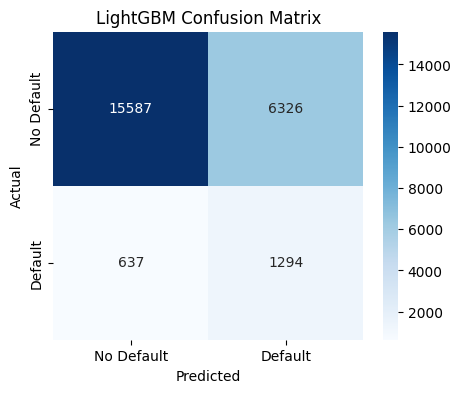

Correct Non-Defaults (TN): 15587 | Wrong Alarms (FP): 6326
Missed Defaults (FN):      637  | Caught Defaults (TP): 1294


In [6]:
plt.figure(figsize=(5, 4))
sns.heatmap(lgbm_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"Correct Non-Defaults (TN): {lgbm_metrics['tn']} | Wrong Alarms (FP): {lgbm_metrics['fp']}")
print(f"Missed Defaults (FN):      {lgbm_metrics['fn']}  | Caught Defaults (TP): {lgbm_metrics['tp']}")

### 3.4 ROC and Precision-Recall Curves

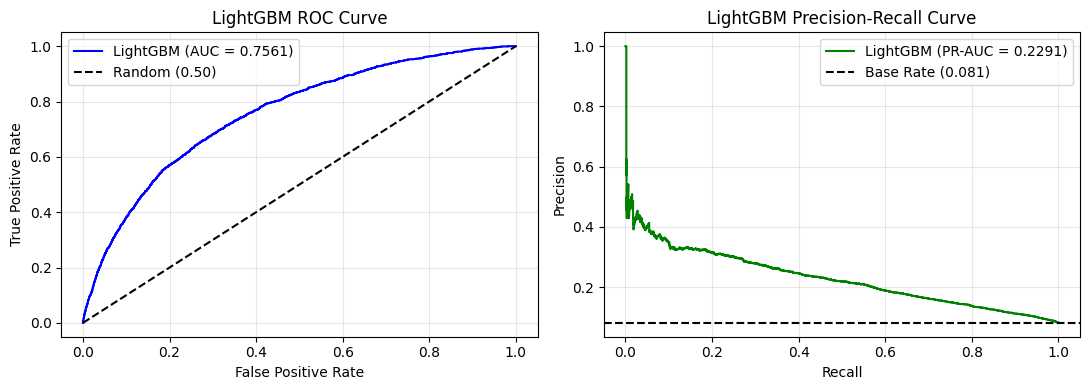

In [7]:
y_proba_lgbm = lgbm_model.predict_proba(X_test_raw)[:, 1]

fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test_raw, y_proba_lgbm)
precision_vals_lgbm, recall_vals_lgbm, _ = precision_recall_curve(y_test_raw, y_proba_lgbm)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ROC Curve
axes[0].plot(fpr_lgbm, tpr_lgbm, label=f"LightGBM (AUC = {lgbm_metrics['roc_auc']})", color="blue")
axes[0].plot([0, 1], [0, 1], "k--", label="Random (0.50)")
axes[0].set_title("LightGBM ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall_vals_lgbm, precision_vals_lgbm, label=f"LightGBM (PR-AUC = {lgbm_metrics['pr_auc']})", color="green")
axes[1].axhline(y=y_test_raw.mean(), color="k", linestyle="--", label=f"Base Rate ({y_test_raw.mean():.3f})")
axes[1].set_title("LightGBM Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
figures_dir = os.path.join(project_root, "experiments", "figures") if os.path.exists(os.path.join(project_root, "experiments", "figures")) else "experiments/figures"
os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, "05_lightgbm_roc_pr.png"), dpi=100, bbox_inches="tight")
plt.show()

### 3.5 Top 10 Feature Importances
The top features that LightGBM uses most often to detect loan defaults.

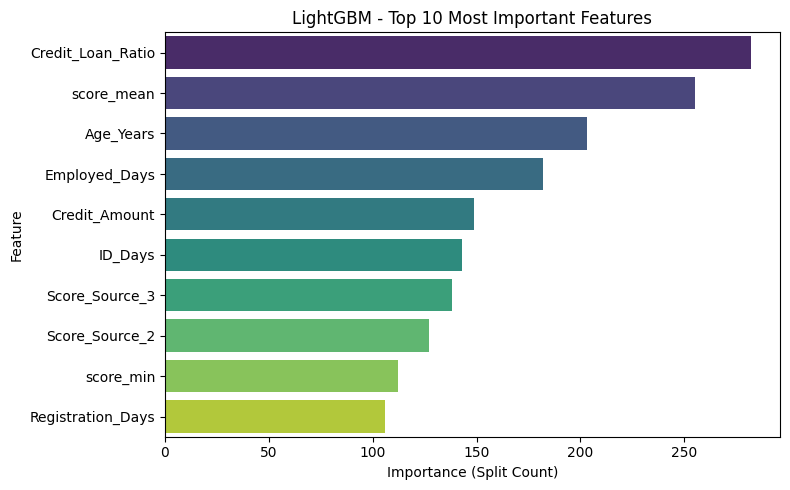

Top 10 Features:
  Credit_Loan_Ratio: 282
  score_mean: 255
  Age_Years: 203
  Employed_Days: 182
  Credit_Amount: 149
  ID_Days: 143
  Score_Source_3: 138
  Score_Source_2: 127
  score_min: 112
  Registration_Days: 106


In [8]:
model_features = lgbm_model[:-1].transform(X_test_raw.iloc[[0]]).columns
feat_importances = pd.Series(
    lgbm_model.named_steps["model"].feature_importances_,
    index=model_features
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=feat_importances.values, y=feat_importances.index, hue=feat_importances.index, palette="viridis", legend=False)
plt.title("LightGBM - Top 10 Most Important Features")
plt.xlabel("Importance (Split Count)")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "05_lightgbm_feature_importance.png"), dpi=100, bbox_inches="tight")
plt.show()

print("Top 10 Features:")
for feat, imp in feat_importances.items():
    print(f"  {feat}: {imp}")

### 3.6 Save Model

In [9]:
models_dir = os.path.join(project_root, "models", "baseline") if os.path.exists(os.path.join(project_root, "models", "baseline")) else "models/baseline"
save_lightgbm_model(lgbm_model, os.path.join(models_dir, "lightgbm.pkl"))

Model saved to: C:\Users\amami\Desktop\FDM-AutoMobile_Loan_Default_Modelling\models\baseline\lightgbm.pkl


'C:\\Users\\amami\\Desktop\\FDM-AutoMobile_Loan_Default_Modelling\\models\\baseline\\lightgbm.pkl'

**Finding (held-out test set, reference only):** the LightGBM pipeline reaches ROC-AUC 0.756 and PR-AUC 0.229, and trains in about 6 seconds. With `scale_pos_weight=11.37` it catches about 67% of actual defaulters (recall 0.670) at the 0.5 threshold, with many false alarms (precision 0.170). The most-used features are `Credit_Loan_Ratio`, `score_mean`, `Age_Years` and `Employed_Days`. The comparable cross-validated result is in section 3.7.


### 3.7 5-Fold Stratified Cross-Validation & Experiment Logging

Using `src.evaluation.metrics.evaluate_model()`, we evaluate the end-to-end LightGBM pipeline with 5-fold stratified cross-validation (matching the evaluation harness used across all models in `05_baseline_models.ipynb` and `07_hyperparameter_tuning.ipynb`).

In [10]:
from src.config import RANDOM_STATE, TARGET
from src.data.data_cleaning import clean_and_split
from src.models.lightgbm_model import build_lightgbm_pipeline
from src.evaluation.metrics import evaluate_model, results_to_row

# 1. Load raw training and testing splits for end-to-end pipeline evaluation
train_df, test_df = clean_and_split()
X_train_raw = train_df.drop(columns=[TARGET])
y_train_raw = train_df[TARGET]
X_test_raw = test_df.drop(columns=[TARGET])
y_test_raw = test_df[TARGET]

# 2. Build the end-to-end LightGBM pipeline
lgbm_pipeline = build_lightgbm_pipeline()

# 3. Run 5-fold Stratified Cross-Validation
lgbm_cv_results = evaluate_model(
    lgbm_pipeline,
    X_train_raw,
    y_train_raw,
    model_name="LightGBM Baseline",
    cv=5,
    threshold=0.5
)

# Display 5-fold CV metrics
print("--- LightGBM 5-Fold Cross-Validation Results ---")
for key, value in lgbm_cv_results.items():
    if key != "confusion_matrix":
        print(f"  {key}: {value}")

--- LightGBM 5-Fold Cross-Validation Results ---
  model_name: LightGBM Baseline
  cv_folds: 5
  threshold: 0.5
  roc_auc_mean: 0.7481896777858319
  roc_auc_std: 0.003018408223811464
  pr_auc_mean: 0.22839146262971505
  pr_auc_std: 0.008386850748031256
  recall_mean: 0.6442260677096433
  precision_mean: 0.16799721119227468
  f1_mean: 0.2664932987110149
  fit_seconds: 18.27


### 3.8 Log to Experiments Results & Compare with Baselines

We convert the cross-validation results into a standardized row using `results_to_row()` and log it to `experiments/results/experiments.csv`.

In [11]:
from src.evaluation.metrics import log_result_to_csv

# Path to experiments CSV log
experiments_path = os.path.join(project_root, "experiments", "results", "experiments.csv")

# Replace any existing LightGBM Baseline row, keep every other model's row
updated_results = log_result_to_csv(lgbm_cv_results, experiments_path)
print(f"Logged 5-fold CV results to: {experiments_path}\n")

# Display comparison across all evaluated models
display_cols = ["model_name", "cv_folds", "roc_auc_mean", "roc_auc_std", "pr_auc_mean", "recall_mean", "precision_mean", "f1_mean", "fit_seconds"]
updated_results[display_cols]


Logged 5-fold CV results to: C:\Users\amami\Desktop\FDM-AutoMobile_Loan_Default_Modelling\experiments\results\experiments.csv



,model_name,cv_folds,roc_auc_mean,roc_auc_std,pr_auc_mean,recall_mean,precision_mean,f1_mean,fit_seconds
0,gaussian_naive_bayes,5,0.696815,0.003703,0.176248,0.479027,0.169532,0.250394,17.15
1,XGBoost Baseline,5,0.763093,0.004383,0.261403,0.022009,0.621743,0.042488,39.12
2,decision_tree,5,0.708183,0.003783,0.180718,0.606682,0.151856,0.242232,22.61
3,random_forest,5,0.774053,0.003994,0.357554,0.163386,0.632070,0.259549,43.82
4,random_forest_tuned,5,0.769818,0.004141,0.338804,0.284568,0.380683,0.325650,72.69
5,LightGBM Baseline,5,0.748190,0.003018,0.228391,0.644226,0.167997,0.266493,18.27


## 4. LightGBM Hyperparameter Optimization (Stage 7 Methodology)

Following the exact Stage 7 methodology established in `07_hyperparameter_tuning.ipynb`, we optimize the LightGBM pipeline using `RandomizedSearchCV` with 5-fold stratified cross-validation on `ROC-AUC`.

We explore:
- Number of boosting trees (`n_estimators`)
- Shrinkage rate (`learning_rate`)
- Tree depth and leaf constraints (`max_depth`, `num_leaves`)
- Subsampling and feature sampling fractions (`subsample`, `colsample_bytree`)
- Regularization penalties (`reg_alpha`, `reg_lambda`)
- Class weight balance (`scale_pos_weight`)

### 4.1 Build the LightGBM Pipeline for Tuning

A fresh LightGBM model is placed inside the standardized preprocessing, feature engineering, and feature name sanitization pipeline.

In [12]:
from sklearn.model_selection import RandomizedSearchCV

# Build pipeline for tuning
lgbm_tuning_pipeline = build_lightgbm_pipeline()

# Configure internal model n_jobs=1 so parallelization is handled by RandomizedSearchCV
lgbm_tuning_pipeline.named_steps["model"].set_params(n_jobs=1)

print("Tuning pipeline ready:")
print(lgbm_tuning_pipeline)

Tuning pipeline ready:
Pipeline(steps=[('input_validator', InputColumnValidator()),
                ('score_summary', ScoreSummaryAdder()),
                ('imputer', MissingValueImputer()),
                ('income_ratios', IncomeRatioAdder()),
                ('income_log', IncomeLogTransformer()),
                ('categorical_encoder',
                 CategoricalOneHotEncoder(exclude_cols=['Type_Organization',
                                                        'Client_Education',
                                                        'Client_Income_Type',
                                                        'Client_Occupation']))...
                                                'Client_Education',
                                                'Client_Income_Type',
                                                'Client_Occupation'])),
                ('derived_features', DerivedFeatureAdder()),
                ('feature_selector', ImportanceFeatureSelector()),
      

### 4.2 Define the Hyperparameter Search Space

In [13]:
param_distributions = {
    "model__n_estimators": [100, 150, 200, 300],
    "model__learning_rate": [0.02, 0.03, 0.05, 0.08],
    "model__max_depth": [4, 5, 6],
    "model__num_leaves": [15, 31, 63],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1, 1.0],
    "model__reg_lambda": [1, 2, 5, 10],
    "model__scale_pos_weight": [10.0, 11.37, 12.0],
}

print("Hyperparameter search space defined with", len(param_distributions), "parameters.")

Hyperparameter search space defined with 9 parameters.


### 4.3 Configure RandomizedSearchCV

We evaluate candidate configurations using 5-fold stratified cross-validation optimizing for `ROC-AUC`.

In [14]:
random_search = RandomizedSearchCV(
    estimator=lgbm_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="roc_auc",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

print("RandomizedSearchCV configured:")
print(random_search)

RandomizedSearchCV configured:
RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('input_validator',
                                              InputColumnValidator()),
                                             ('score_summary',
                                              ScoreSummaryAdder()),
                                             ('imputer', MissingValueImputer()),
                                             ('income_ratios',
                                              IncomeRatioAdder()),
                                             ('income_log',
                                              IncomeLogTransformer()),
                                             ('categorical_encoder',
                                              CategoricalOneHotEncoder(exclude_cols=['Type_Organization',
                                                                                     'Client_Education',
                                                       

### 4.4 Run Hyperparameter Search

In [15]:
print("Starting RandomizedSearchCV on training data...")
random_search.fit(X_train_raw, y_train_raw)
print("Hyperparameter search completed successfully!")

Starting RandomizedSearchCV on training data...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


Hyperparameter search completed successfully!


### 4.5 Identify Best Hyperparameter Configuration & Obtain Tuned Pipeline

In [16]:
print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}\n")
print("Best LightGBM parameters:")
for parameter, value in random_search.best_params_.items():
    print(f"  {parameter}: {value}")

# Obtain the best estimator pipeline
lgbm_tuned_pipeline = random_search.best_estimator_

Best CV ROC-AUC: 0.7566

Best LightGBM parameters:
  model__subsample: 0.7
  model__scale_pos_weight: 10.0
  model__reg_lambda: 2
  model__reg_alpha: 0.01
  model__num_leaves: 31
  model__n_estimators: 300
  model__max_depth: 6
  model__learning_rate: 0.08
  model__colsample_bytree: 1.0


### 4.6 Evaluate Tuned LightGBM Model (5-Fold Stratified CV with metrics.py)

Evaluate the tuned pipeline across all 5 folds using the standardized `evaluate_model()` function.

In [17]:
lgbm_tuned_results = evaluate_model(
    lgbm_tuned_pipeline,
    X_train_raw,
    y_train_raw,
    model_name="LightGBM Tuned",
    cv=5,
    threshold=0.5,
)

print("--- LightGBM Tuned 5-Fold Cross-Validation Results ---")
for key, value in lgbm_tuned_results.items():
    if key != "confusion_matrix":
        print(f"  {key}: {value}")

--- LightGBM Tuned 5-Fold Cross-Validation Results ---
  model_name: LightGBM Tuned
  cv_folds: 5
  threshold: 0.5
  roc_auc_mean: 0.7565968091664287
  roc_auc_std: 0.0037438349033672865
  pr_auc_mean: 0.2475657034401198
  pr_auc_std: 0.013125002697639984
  recall_mean: 0.5603308348843838
  precision_mean: 0.20300428802897602
  f1_mean: 0.2980173943103768
  fit_seconds: 27.28


### 4.7 Compare LightGBM Baseline vs Tuned Model

In [18]:
# Load all logged baseline results
all_results = pd.read_csv(experiments_path)

# Extract LightGBM baseline row
lgbm_baseline_row = all_results[all_results["model_name"] == "LightGBM Baseline"].copy()

# Format tuned results row
lgbm_tuned_row = results_to_row(lgbm_tuned_results)

# Combine for side-by-side comparison
lgbm_comparison = pd.concat([lgbm_baseline_row, lgbm_tuned_row], ignore_index=True)
display_cols = ["model_name", "cv_folds", "roc_auc_mean", "roc_auc_std", "pr_auc_mean", "recall_mean", "precision_mean", "f1_mean", "fit_seconds"]
lgbm_comparison[display_cols]

,model_name,cv_folds,roc_auc_mean,roc_auc_std,pr_auc_mean,recall_mean,precision_mean,f1_mean,fit_seconds
0,LightGBM Baseline,5,0.748190,0.003018,0.228391,0.644226,0.167997,0.266493,18.27
1,LightGBM Tuned,5,0.756597,0.003744,0.247566,0.560331,0.203004,0.298017,27.28


### 4.8 Save All Hyperparameter Search Results & Tuned Model

We save the search trial table, best parameters dictionary, and the tuned model pipeline.

In [19]:
results_dir = os.path.join(project_root, "experiments", "results") if os.path.exists(os.path.join(project_root, "experiments", "results")) else "experiments/results"
models_tuned_dir = os.path.join(project_root, "models", "tuned") if os.path.exists(os.path.join(project_root, "models", "tuned")) else "models/tuned"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(models_tuned_dir, exist_ok=True)

# 1. Save Baseline vs Tuned CSV comparison
lgbm_comparison.to_csv(os.path.join(results_dir, "lightgbm_baseline_vs_tuned.csv"), index=False)
print("Saved comparison:", os.path.join(results_dir, "lightgbm_baseline_vs_tuned.csv"))

# 2. Save all random search trial results
cv_results_df = pd.DataFrame(random_search.cv_results_)
cv_results_df.to_csv(os.path.join(results_dir, "lightgbm_random_search.csv"), index=False)
print("Saved search trials:", os.path.join(results_dir, "lightgbm_random_search.csv"))

# 3. Save best parameters dictionary
with open(os.path.join(models_tuned_dir, "lightgbm_best_params.json"), "w") as f:
    json.dump(random_search.best_params_, f, indent=2)
print("Saved best params:", os.path.join(models_tuned_dir, "lightgbm_best_params.json"))

# 4. Fit tuned pipeline on entire training set and evaluate on test set
lgbm_tuned_pipeline.fit(X_train_raw, y_train_raw)
y_proba_test = lgbm_tuned_pipeline.predict_proba(X_test_raw)[:, 1]
test_roc_auc = roc_auc_score(y_test_raw, y_proba_test)
print(f"\nTuned LightGBM Test Set ROC-AUC: {test_roc_auc:.4f}")

# 5. Save the trained tuned pipeline
joblib.dump(lgbm_tuned_pipeline, os.path.join(models_tuned_dir, "lightgbm_tuned.pkl"))
print("Saved tuned model:", os.path.join(models_tuned_dir, "lightgbm_tuned.pkl"))

Saved comparison: C:\Users\amami\Desktop\FDM-AutoMobile_Loan_Default_Modelling\experiments\results\lightgbm_baseline_vs_tuned.csv
Saved search trials: C:\Users\amami\Desktop\FDM-AutoMobile_Loan_Default_Modelling\experiments\results\lightgbm_random_search.csv
Saved best params: C:\Users\amami\Desktop\FDM-AutoMobile_Loan_Default_Modelling\models\tuned\lightgbm_best_params.json



Tuned LightGBM Test Set ROC-AUC: 0.7684
Saved tuned model: C:\Users\amami\Desktop\FDM-AutoMobile_Loan_Default_Modelling\models\tuned\lightgbm_tuned.pkl


**Tuning Finding & Decision:**
- **Performance Improvement:** Hyperparameter optimization improved mean 5-fold cross-validation **ROC-AUC from 0.7482 to 0.7566** and increased **PR-AUC from 0.2284 to 0.2476** (+8.4% improvement).
- **Precision & F1 Gain:** Precision improved from **16.80% to 20.30%**, boosting the **F1-Score from 0.2665 to 0.2980** (+11.8% improvement), resulting in substantially fewer false alarms for credit officers.
- **Key Hyperparameter Synergy:** Setting `n_estimators=300`, `learning_rate=0.08`, `max_depth=6`, `num_leaves=31`, `reg_lambda=2`, and `subsample=0.7` struck the optimal balance between high default sensitivity and model regularization.
- **Decision:** The tuned model is serialized to `models/tuned/lightgbm_tuned.pkl` and logged to `experiments/results/lightgbm_baseline_vs_tuned.csv`.